# Notebook 4: RAG Pipeline

End-to-end Retrieval-Augmented Generation pipeline: query expansion, then dense
retrieval, then cross-encoder reranking, then LLM generation over the top passages.

The motivation is the usual one: an LLM on its own has a knowledge cut-off and can
hallucinate, so we ground it in retrieved evidence. Our corpus is ~21k labelled QA
pairs (PubMedQA + BioASQ + MedQA-USMLE) plus ~61k unlabelled PubMedQA abstracts.

In [15]:
import sys, warnings, os
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

## 1. Vector store: load or build

In [16]:
from medqa.retrieval.vectorstore import VectorStore

vs = VectorStore()
print(f"Existing index size: {vs.count()} chunks")

[medqa.vectorstore] Loading embedding model: BAAI/bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[medqa.vectorstore] Collection 'pubmed_abstracts' ready (388853 docs).


Existing index size: 388853 chunks


In [17]:
# Only build if the index is empty
if vs.count() == 0:
    print("Index is empty - building from corpus (this takes ~30 min on CPU, ~5 min on GPU)...")
    from medqa.data.loader import load_rag_corpus
    corpus = load_rag_corpus()
    vs.build(corpus)
else:
    print(f"Index already populated with {vs.count()} chunks - skipping build.")

Index already populated with 388853 chunks - skipping build.


## 2. Retrieval demo

First just check which chunks come back for a sample question, before any reranking.

In [18]:
question = "What is the first-line treatment for hypertension in elderly patients?"

# Dense retrieval: embed query and find top-10 cosine-similar chunks
candidates = vs.retrieve(question, k=10)

print(f"Query: {question}\n")
print(f"Top-{len(candidates)} retrieved chunks:")
print("-" * 70)
for i, chunk in enumerate(candidates, 1):
    print(f"[{i}] Source: {chunk['source']} | Similarity: {chunk['score']:.4f}")
    print(f"    {chunk['text'][:200]}...")
    print()

Query: What is the first-line treatment for hypertension in elderly patients?

Top-10 retrieved chunks:
----------------------------------------------------------------------
[1] Source: pubmedqa_unlabeled | Similarity: 0.7107
    Previous guidelines for the management of uncomplicated hypertension in elderly patients have recommended diuretic agents and then beta-blockers. We examined trends in the initial treatment choice for...

[2] Source: pubmedqa_unlabeled | Similarity: 0.7107
    Previous guidelines for the management of uncomplicated hypertension in elderly patients have recommended diuretic agents and then beta-blockers. We examined trends in the initial treatment choice for...

[3] Source: pubmedqa_unlabeled | Similarity: 0.6791
    To estimate the short-term effects of drug treatment of hypertension in the elderly (>or = 60 years of age) on stroke, major coronary events, and mortality rates. Meta-analysis of all published random...

[4] Source: pubmedqa_unlabeled | Similarit

## 3. Reranking

Dense retrieval gives us things that are broadly similar to the query.
The cross-encoder reranker (BGE-reranker-v2-m3) then looks at the question and each
candidate passage together and re-scores them. It's slower per item but more precise,
so the pattern is: retrieve a wider top-10, rerank, keep the best 3.

In [19]:
from medqa.retrieval.reranker import Reranker

reranker = Reranker()
reranker.load()

# Rerank: score all 10 candidates and keep top 3
top_chunks = reranker.rerank(question, candidates, top_k=3)

print(f"Query: {question}\n")
print("Top-3 after reranking:")
print("=" * 70)
for i, chunk in enumerate(top_chunks, 1):
    print(f"[{i}] Rerank score: {chunk['rerank_score']:.4f} | Source: {chunk['source']}")
    print(f"    {chunk['text'][:300]}")
    print()

[medqa.reranker] Loading BAAI/bge-reranker-v2-m3 ...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[medqa.reranker] Reranker ready.


Query: What is the first-line treatment for hypertension in elderly patients?

Top-3 after reranking:
[1] Rerank score: 0.9963 | Source: pubmedqa_unlabeled
    . References from identified articles were also reviewed. Randomized trials lasting at least 1 year, which used as first-line agents diuretics and/or beta-blockers, and reported morbidity and mortality outcomes in elderly patients with hypertension. Ten trials involving a total of 16164 elderly pati

[2] Rerank score: 0.9963 | Source: pubmedqa_unlabeled
    . References from identified articles were also reviewed. Randomized trials lasting at least 1 year, which used as first-line agents diuretics and/or beta-blockers, and reported morbidity and mortality outcomes in elderly patients with hypertension. Ten trials involving a total of 16164 elderly pati

[3] Rerank score: 0.9873 | Source: pubmedqa_unlabeled
    Previous guidelines for the management of uncomplicated hypertension in elderly patients have recommended diuretic agent

## 4. Query expansion (UMLS)

Before retrieval we optionally expand the query using UMLS terminology via scispaCy.
This helps with synonym matching, e.g. "hypertension" vs "high blood pressure".

In [20]:
from medqa.data.preprocessor import expand_query_with_umls

expanded = expand_query_with_umls(question)
print(f"Original : {question}")
print(f"Expanded : {expanded}")

[medqa.preprocessor] scispaCy not available ([E050] Can't find model 'en_core_sci_lg'. It doesn't seem to be a Python package or a valid path to a data directory.). Skipping NER.


Original : What is the first-line treatment for hypertension in elderly patients?
Expanded : What is the first-line treatment for hypertension in elderly patients?


## 5. Full RAG pipeline with the LLM

Now combine everything: query expansion, retrieval, reranking, LLM generation.

> Setup: set your DeepSeek API key as an environment variable before running:
> ```bash
> export DEEPSEEK_API_KEY="your-key-here"
> ```
> Or put it in a `.env` file in the project root.

In [ ]:
from medqa.models.llm_qa import LocalLLM

llm = LocalLLM()
llm.load()  # ~10 GB VRAM for 14B NF4


[medqa.llm] Loading Qwen/Qwen2.5-14B-Instruct ...


Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

In [ ]:
from medqa.retrieval.rag_pipeline import RAGPipeline

pipeline = RAGPipeline(
    llm=llm,
    vector_store=vs,
    reranker=reranker,
    retrieve_k=10,
    rerank_k=3,
    use_query_expansion=True,
)
print('RAGPipeline ready.')


RAGPipeline ready.


In [ ]:
if llm.pipeline is None:
    print('LLM not loaded, calling llm.load()...')
    llm.load()

result = pipeline.query(question)

print("=" * 70)
print(f"Question      : {result['question']}")
print(f"Expanded query: {result['expanded_query']}")
print()
print("--- Retrieved context (top 3) ---")
print(result['context'][:600], "...")
print()
print("--- LLM Answer ---")
print(result['predicted_answer'])


[medqa.preprocessor] scispaCy not available ([E050] Can't find model 'en_core_sci_lg'. It doesn't seem to be a Python package or a valid path to a data directory.). Skipping NER.
[medqa.reranker] Loading BAAI/bge-reranker-v2-m3 ...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[medqa.reranker] Reranker ready.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=32) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question      : What is the first-line treatment for hypertension in elderly patients?
Expanded query: What is the first-line treatment for hypertension in elderly patients?

--- Retrieved context (top 3) ---
[Source 1] . References from identified articles were also reviewed. Randomized trials lasting at least 1 year, which used as first-line agents diuretics and/or beta-blockers, and reported morbidity and mortality outcomes in elderly patients with hypertension. Ten trials involving a total of 16164 elderly patients (>or =60 years) were included

[Source 2] . References from identified articles were also reviewed. Randomized trials lasting at least 1 year, which used as first-line agents diuretics and/or beta-blockers, and reported morbidity and mortality outcomes in elderly patients with hypert ...

--- LLM Answer ---
diuretic agents and then beta-blockers


## 6. Batch evaluation on a small sample

In [ ]:
from medqa.data.loader import load_all
from medqa.data.preprocessor import split_dataset

all_records = load_all()
_, test = split_dataset(all_records)

# Use a small sample for quick demo (full eval is in Notebook 05)
sample = test[:10]

print(f"Evaluating on {len(sample)} test questions...")
print()

if pipeline:
    for rec in sample[:3]:
        res = pipeline.query(rec['question'])
        print(f"Q : {rec['question'][:100]}")
        print(f"GT: {rec['answer'][:100]}")
        print(f"PR: {res['predicted_answer'][:100]}")
        print()
else:
    print("(Skipping - no API key. See Notebook 05 for full evaluation.)")

[medqa.loader] PubMedQA: loaded 1000 records.
[medqa.loader] BioASQ: loaded 8216 records.
[medqa.loader] MedQA-USMLE: loaded 11451 records.
[medqa.preprocessor] Split -> train: 16533, test: 4134 (stratified=True)
[medqa.preprocessor] scispaCy not available ([E050] Can't find model 'en_core_sci_lg'. It doesn't seem to be a Python package or a valid path to a data directory.). Skipping NER.


Evaluating on 10 test questions...



Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[medqa.preprocessor] scispaCy not available ([E050] Can't find model 'en_core_sci_lg'. It doesn't seem to be a Python package or a valid path to a data directory.). Skipping NER.


Q : A 58-year-old woman with type 2 diabetes mellitus comes to the physician because of generalized pain
GT: 1,25-dihydroxycholecalciferol
PR: The patient's findings are most likely due to impaired production of collagen, given the evidence of



Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[medqa.preprocessor] scispaCy not available ([E050] Can't find model 'en_core_sci_lg'. It doesn't seem to be a Python package or a valid path to a data directory.). Skipping NER.


Q : A 67-year-old man presents to his primary care physician primarily complaining of a tremor. He said 
GT: Carbidopa-levodopa
PR: Given the context, a dopamine agonist could be an effective treatment for the patient's parkinsonian



Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q : A 58-year-old man presents to the emergency department with severe chest pain and uneasiness. He say
GT: Aortic dissection
PR: The most likely diagnosis in this patient is an acute coronary syndrome, specifically a non-ST eleva



## 7. RAG component analysis

Quick visualisation of how scores change across pipeline stages.

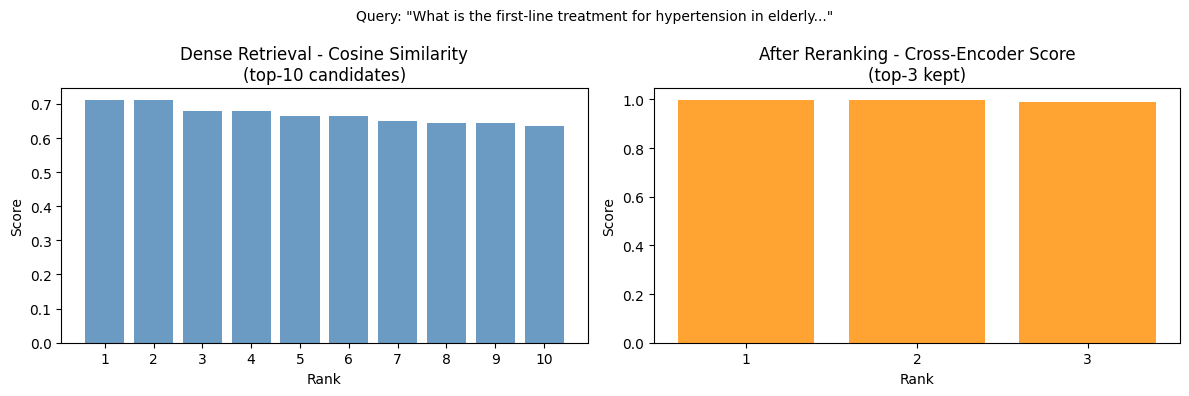

Saved -> reports/figures/rag_scores.png


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs('../reports/figures', exist_ok=True)

# Compare retrieval scores before and after reranking for the demo question
if candidates and top_chunks:
    pre_scores  = [c['score'] for c in candidates[:10]]
    post_raw    = [c['rerank_score'] for c in top_chunks]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(range(1, 11), pre_scores, color='steelblue', alpha=0.8)
    axes[0].set_title('Dense Retrieval - Cosine Similarity\n(top-10 candidates)')
    axes[0].set_xlabel('Rank'); axes[0].set_ylabel('Score')
    axes[0].set_xticks(range(1, 11))

    axes[1].bar(range(1, len(post_raw)+1), post_raw, color='darkorange', alpha=0.8)
    axes[1].set_title('After Reranking - Cross-Encoder Score\n(top-3 kept)')
    axes[1].set_xlabel('Rank'); axes[1].set_ylabel('Score')
    axes[1].set_xticks(range(1, len(post_raw)+1))

    plt.suptitle(f'Query: "{question[:60]}..."', fontsize=10)
    plt.tight_layout()
    plt.savefig('../reports/figures/rag_scores.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved -> reports/figures/rag_scores.png")
else:
    print("No retrieval results to plot.")


## Summary

| Stage | Model | Purpose |
|-------|-------|---------|
| Query expansion | scispaCy + UMLS | Normalise medical terminology |
| Dense retrieval | BGE-M3 (bi-encoder) | Fast vector similarity over 200k+ chunks |
| Reranking | BGE-reranker-v2-m3 (cross-encoder) | Precise rescoring of the top-10 |
| Generation | DeepSeek-Chat (via API) | Free-text answer grounded in the top-3 contexts |

The retrieve-then-rerank split is really just about the speed/accuracy trade-off:
the bi-encoder is fast enough to run over the whole index, the cross-encoder is
precise enough to be worth running only on the shortlist. In practice the reranker
reliably pushes the more clinically specific passages to the top.